In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(f"D:\Car\Customer_Segmentation\Course_ML_Project\AI_Impact_on_Jobs_2030.csv")

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Hp\AppData\Local\Temp\ipykernel_24364\1434565926.py:1: SyntaxWarning: invalid escape sequence '\C'
  df=pd.read_csv(f"D:\Car\Customer_Segmentation\Course_ML_Project\AI_Impact_on_Jobs_2030.csv")


In [3]:
df.head()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [4]:
df.shape

(3000, 18)

<Axes: xlabel='Education_Level', ylabel='Years_Experience'>

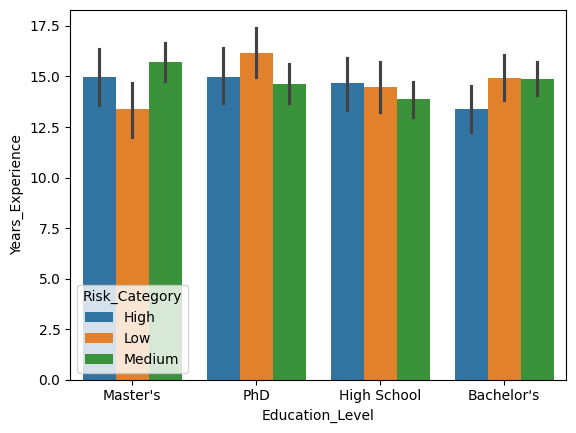

In [5]:
sns.barplot(data=df,x="Education_Level",y="Years_Experience",hue="Risk_Category")

<Axes: xlabel='Average_Salary', ylabel='Job_Title'>

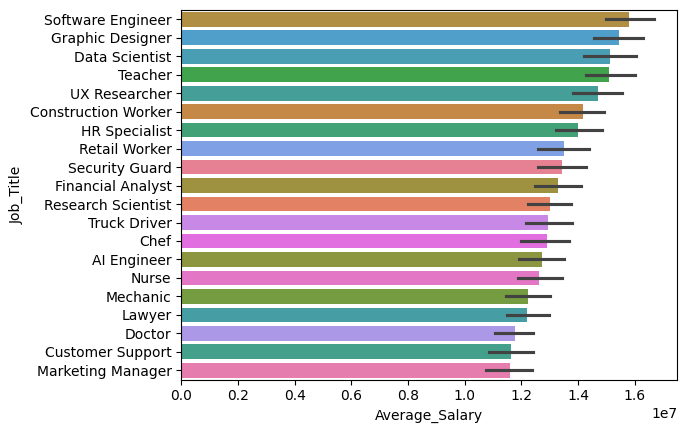

In [6]:
ascending_order=df.groupby("Job_Title")["Average_Salary"].sum().sort_values(ascending=False).index
sns.barplot(data=df,y="Job_Title",x="Average_Salary",hue="Job_Title",order=ascending_order,estimator="sum")

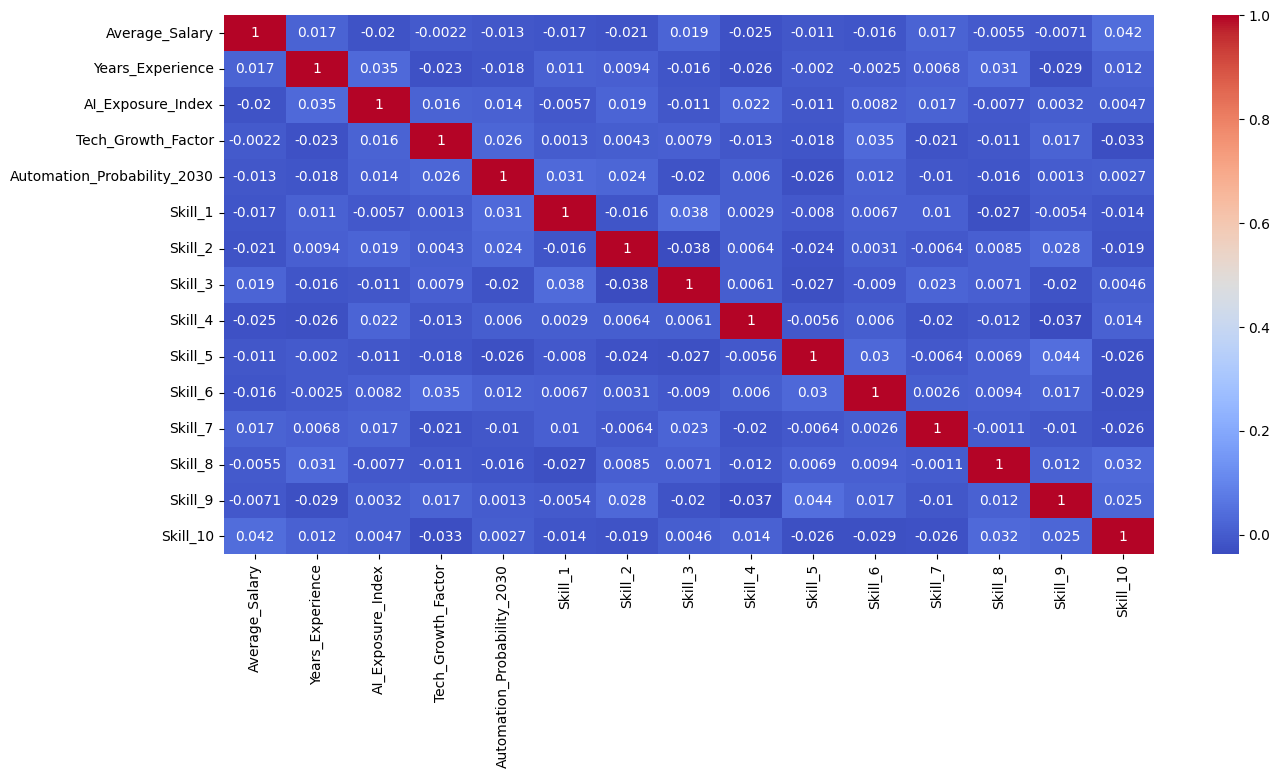

In [7]:
numeric_df=df.select_dtypes(include=np.number)
plt.figure(figsize=(15,7))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [8]:
df.describe()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
Education_mapping={"High School":1,"Bachelor's":2,"Master's":3,"PhD":4}
Risk_mapping={"Low":1,"Medium":2,"High":3}

df["Education_Level_Encoded"]=df["Education_Level"].map(Education_mapping)
df["Risk_Category_Encoded"]=df["Risk_Category"].map(Risk_mapping)

df["Job_Title_Encoded"]=encoder.fit_transform(df["Job_Title"])
df_encoded=df.drop(columns=["Job_Title","Education_Level","Risk_Category"],inplace=True)

In [10]:
df.head()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Education_Level_Encoded,Risk_Category_Encoded,Job_Title_Encoded
0,45795,28,0.18,1.28,0.85,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00,3,3,15
1,133355,20,0.62,1.11,0.05,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98,4,1,13
2,146216,2,0.86,1.18,0.81,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83,1,3,2
3,136530,13,0.39,0.68,0.60,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33,4,2,16
4,70397,22,0.52,1.46,0.64,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42,1,2,6


In [11]:
safe_features=["Job_Title_Encoded", "Average_Salary", "Years_Experience", "Education_Level_Encoded", 
    "AI_Exposure_Index", "Tech_Growth_Factor",
    "Skill_1", "Skill_2", "Skill_3", "Skill_4", "Skill_5", 
    "Skill_6", "Skill_7", "Skill_8", "Skill_9", "Skill_10"]

In [12]:
X=df.drop(["Risk_Category_Encoded","Automation_Probability_2030"],axis=1)

In [13]:
X.head()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Education_Level_Encoded,Job_Title_Encoded
0,45795,28,0.18,1.28,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00,3,15
1,133355,20,0.62,1.11,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98,4,13
2,146216,2,0.86,1.18,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83,1,2
3,136530,13,0.39,0.68,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33,4,16
4,70397,22,0.52,1.46,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42,1,6


In [14]:
from sklearn.model_selection import train_test_split
#X=df[safe_features]
y=df["Risk_Category_Encoded"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

lr_model = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=1000))])

dt_model = Pipeline([("scaler", StandardScaler()),("model", DecisionTreeClassifier(random_state=42))])

rf_model = Pipeline([("scaler", StandardScaler()),("model", RandomForestClassifier(random_state=42, n_jobs=-1))])

gb_model = Pipeline([("scaler", StandardScaler()),("model", GradientBoostingClassifier(random_state=42))])

knn_model = Pipeline([("scaler", StandardScaler()),("model", KNeighborsClassifier())])

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "KNN": knn_model
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append([name, accuracy, precision, recall, f1])

results_df = pd.DataFrame(results,columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
3    Gradient Boosting  0.991667   0.991724  0.991667  0.991658
1        Decision Tree  0.981667   0.981814  0.981667  0.981671
2        Random Forest  0.938333   0.940814  0.938333  0.938027
0  Logistic Regression  0.471667   0.223628  0.471667  0.303405
4                  KNN  0.425000   0.405268  0.425000  0.396202
